<br/><br/><div id="top"></div>
<center><a style="font-size: 40pt; font-weight: bold">
    Être ou ne pas être ?
</a></center>
<br/>
---

# Membres du groupe
* Lahouaoui Islam
* Abdelhadi Nouh
* Slimani Mohamed Chakib

### Objectif :
L'objectif est de créer un modèle capable d'apprendre à partir des données et de faire des prédictions (apprentissage supervisé). Chaque instance (patient·e) possède une variable indiquant si elle·il est décédé·e ou non pendant son séjour à l'hôpital.


### Structure du projet :
1. __Découverte des données__ : Chargement des données afin d'explorer les variables disponibles.
2. __Nettoyage, exploration et visualisation des données__ : Filtrage du jeu de données, et visualiser les données pour juger nos hypothèses.
3. __Feature engineering__ : Enrichissement du dataset pour tester les modèles et améliorer les prédictions.
4. __Modélisation__ : Construction d'un modèle de classification.
5. __Evaluation__ : Comparaison des modèles pour évaluer les performances.
6. __Interprétation et Conclusion__

## Découverte des données

Dans cette partie, nous chargeons les données et réalisons une première familiarisation afin de comprendre la structure du fichier et identifier les éléments pertinents pour le dataset.

In [145]:
# Importation des bibliothèques essentielles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [56]:
# Chargement des noms de colonnes (features) et étiquettes (labels)
features = pd.read_csv("data/mimic_synthetic_feat.name", header=None).values.flatten()
labels = pd.read_csv("data/mimic_synthetic_label.name", header=None).values.flatten()
# Chargement des données d'entraînement (X)
x_df = pd.read_csv(
    "data/mimic_synthetic_train.data",
    header=None,
    names=features,
    sep=" ",
)

# Chargement des étiquettes cibles (y)
ys = pd.Series(
    pd.read_csv(
        "data/mimic_synthetic_train.solution",
        header=None,
        names=labels,
        sep=" ",
    ).values.flatten()
)


In [57]:
# Aperçu des premières lignes
x_df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,45524,108398,2128-05-15_23:42:00,2132-07-23_15:00:00,Private,ENGL,CATHOLIC,DIVORCED,WHITE,F,...,0,0,0,0,0,0.0,0,0,0,0
1,50520,186416,2134-03-17_03:59:00,2113-03-06_12:05:00,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,M,...,0,0,0,0,0,0.0,0,0,0,1
2,17956,126413,2164-04-05_17:32:00,2180-09-20_16:30:00,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,M,...,0,0,0,0,0,0.0,0,0,0,0
3,90258,109355,2102-09-08_00:58:00,2166-06-26_15:30:00,Medicare,ENGL,NOT_SPECIFIED,MARRIED,WHITE,M,...,0,0,0,0,0,0.0,0,0,1,0
4,25159,123784,2163-08-06_12:07:00,2147-01-14_18:40:00,Medicare,ENGL,UNOBTAINABLE,MARRIED,UNKNOWN/NOT_SPECIFIED,F,...,0,0,0,0,0,0.0,0,0,0,0


In [58]:
print(f"Dimensions de X () : {x_df.shape}")
print(f"Dimensions de y : {ys.shape}")
print(f"Exemples de features : {features[:5]}")
# Afficher la cible de la premiere personne 
print(f"Label cible : {labels[0]}")


Dimensions de X () : (79999, 341)
Dimensions de y : (79999,)
Exemples de features : ['SUBJECT_ID' 'HADM_ID' 'ADMITTIME' 'DISCHTIME' 'INSURANCE']
Label cible : DIED


On remarque que le nombre d’exemples (79 999 lignes) dans notre jeu de données est identique à celui de la variable cible y. Cela confirme que chaque patient possède une étiquette associée (décès ou non), ce qui est essentiel pour l’apprentissage de notre modele.

In [63]:
x_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79999 entries, 0 to 79998
Columns: 341 entries, SUBJECT_ID to Htncomplicn
dtypes: float64(51), int64(281), object(9)
memory usage: 208.7+ MB


#### Types de données :

float64 : 51 colonnes contiennent des valeurs décimales (ex: pression sanguine, etc.)

int64 : 281 colonnes avec des entiers (ex: booléens 0/1, décomptes…)

object : 9 colonnes contiennent du texte (ex: sexe, assurance, langue…)

In [65]:
x_df.describe()

,SUBJECT_ID,HADM_ID,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,SYS_BP_MIN_DAY1,SYS_BP_MAX_DAY1,SYS_BP_MEAN_DAY1,DIAS_BP_MIN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
count,79999.000000,79999.000000,79999.000000,79999.000000,79999.000000,79999.000000,79999.000000,79999.000000,79999.000000,79999.000000,...,79999.0,79999.000000,79999.0,79999.0,79999.0,79998.000000,79999.000000,79999.000000,79999.000000,79999.000000
mean,37927.384230,150061.011025,62.660546,71.648531,103.083037,86.394036,94.612069,147.790712,119.655538,45.243690,...,0.0,0.000013,0.0,0.0,0.0,0.145454,0.134177,0.008625,0.457693,0.078976
std,29300.394392,29005.267607,18.193723,14.652553,18.479082,15.510917,16.940341,21.609206,16.486749,10.499518,...,0.0,0.003536,0.0,0.0,0.0,0.352560,0.340844,0.092471,0.498210,0.269703
min,3.000000,100001.000000,16.000000,18.728695,49.860610,38.503600,31.768501,91.693405,73.968796,11.334383,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13853.000000,124750.000000,51.000000,61.458639,89.897490,75.284898,82.811535,132.121700,107.559967,37.831446,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27591.000000,150045.000000,65.000000,71.049320,101.585940,85.421690,94.168460,145.412140,118.117890,44.621235,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,62471.000000,175452.000000,77.000000,81.148908,114.800830,96.505275,105.964120,161.115990,130.294615,51.966651,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000
max,99999.000000,199999.000000,90.000000,141.859680,206.621150,157.612470,163.822920,260.044980,186.328400,95.604270,...,0.0,1.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000


Les statistiques montrent que la majorité des patients ont un âge moyen d'environ 62 ans. Les constantes vitales, comme la fréquence cardiaque et la pression artérielle, varient largement d'un patient à l'autre. Certaines variables, comme les infections oculaires, sont très rares et contiennent principalement des valeurs égales à 0.

#### Explorer les valeurs manquantes

In [115]:
# Calcul du pourcentage de valeurs manquantes pour chaque colonne
missing_percent = x_df.isnull().mean() * 100

# Afficher uniquement les colonnes avec des valeurs manquantes
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

ECodes:Adverseeffectsofmedicalcare    0.00750
ICU                                   0.00250
Otnutritdx                            0.00250
LANGUAGE                              0.00125
MARITAL_STATUS                        0.00125
Othnervdx                             0.00125
dtype: float64


- Très peu de valeurs sont manquantes dans notre jeu de données (moins de 0.01% par colonne concernée).
- Cela montre que le dataset est globalement propre, et qu’il n’est pas nécessaire de supprimer des colonnes ou des lignes entières.

#### Visualisation des variables clés
Et enfin on va visualiser la distribution des variables clés.

#### Distribution de la variable cible

In [71]:
ys.describe()

count    79999.000000
mean         0.034963
std          0.183687
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
dtype: float64

Cela confirme ce qu’on a observé précédemment : chaque patient est associé à un état (vivant ou décédé)

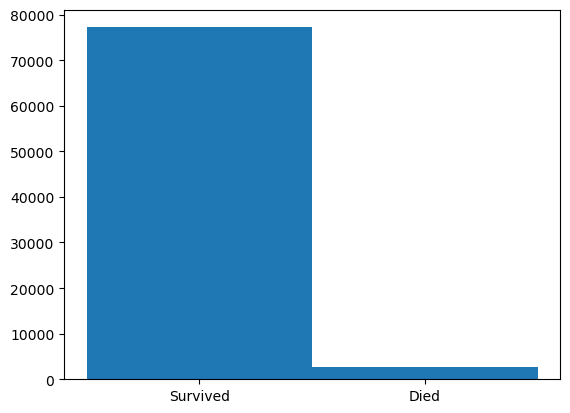

In [78]:
ys.hist(bins=2, grid=False, align="left")
plt.xticks([0, 0.5], ["Survived", "Died"])
plt.show()

Nous visualisons ici la distribution des différentes valeurs de la colonne MARITAL_STATUS afin de mieux comprendre la répartition des patients selon leur situation .

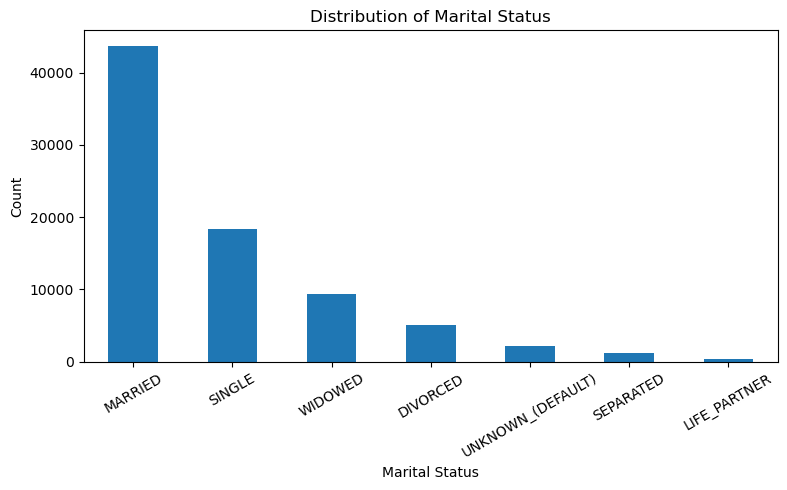

In [86]:
plt.figure(figsize=(8, 5))
x_marital_cnts = x_df["MARITAL_STATUS"].value_counts()
x_marital_cnts.plot.bar(rot=30)
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Distribution of Marital Status")
plt.tight_layout()
plt.show()

Et voici les 10 religions les plus représentées dans le jeu de données.

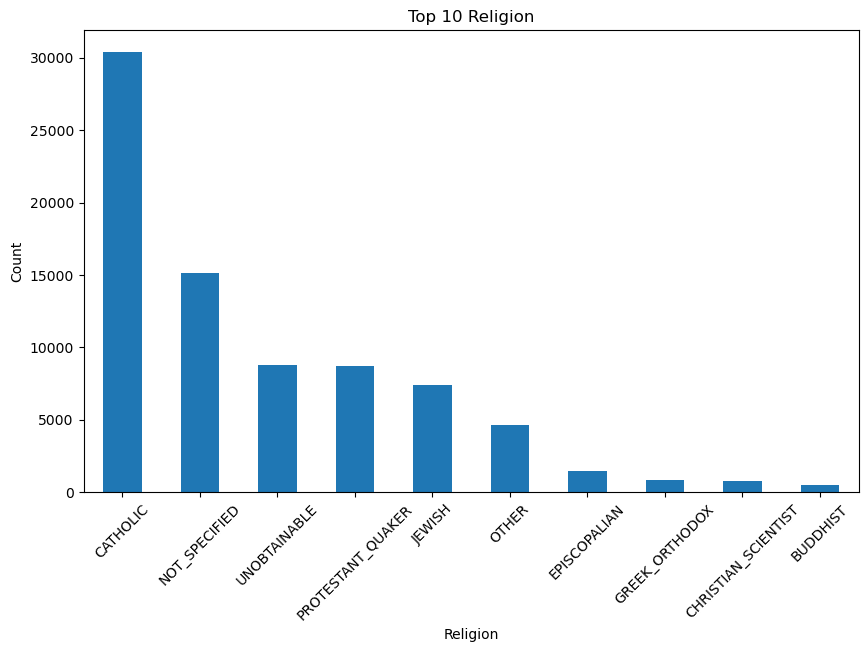

In [105]:
# Sélectionner les 10 catégories les plus fréquentes
top_10_ethnicities = x_df["RELIGION"].value_counts().nlargest(10)

# Créer le graphique à barres pour les 10 catégories les plus fréquentes
plt.figure(figsize=(10, 6))
top_10_ethnicities.plot(kind='bar', rot=45)
plt.xlabel('Religion')
plt.ylabel('Count')
plt.title('Top 10 Religion')
plt.show()

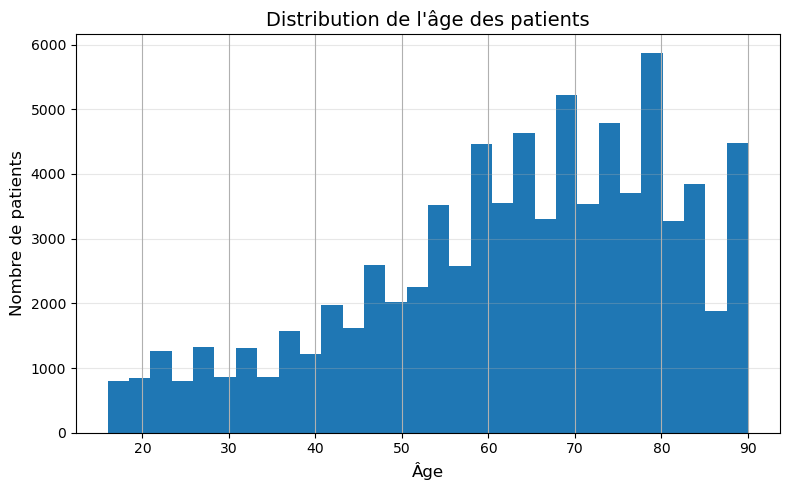

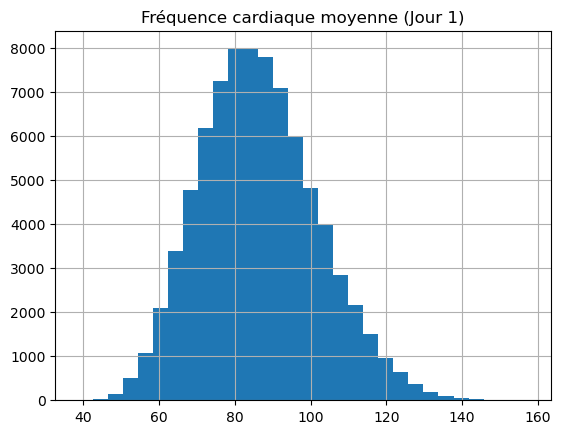

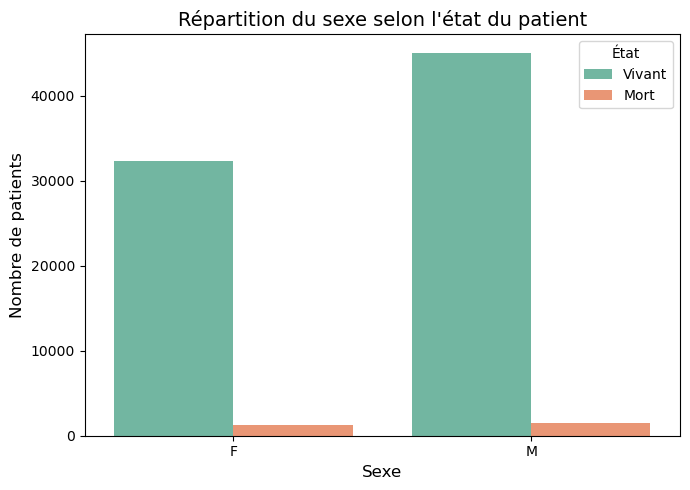

In [114]:
#Distribution de l'age
plt.figure(figsize=(8, 5))
x_df["AGE"].hist(bins=30)
plt.title("Distribution de l'âge des patients", fontsize=14)
plt.xlabel("Âge", fontsize=12)
plt.ylabel("Nombre de patients", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

x_df["HR_MEAN_DAY1"].hist(bins=30)
plt.title("Fréquence cardiaque moyenne (Jour 1)")

plt.figure(figsize=(7, 5))
sns.countplot(x="GENDER", hue=ys, data=x_df, palette="Set2")
plt.title("Répartition du sexe selon l'état du patient", fontsize=14)
plt.xlabel("Sexe", fontsize=12)
plt.ylabel("Nombre de patients", fontsize=12)
plt.legend(title="État", labels=["Vivant", "Mort"])
plt.tight_layout()
plt.show()

Distribution de  **l'age** :
- La majorité des patients ont plus de 50 ans, ce qui indique une population principalement âgée dans cet ensemble de données.
- Cela pourrait refléter une plus grande vulnérabilité des personnes âgées aux problèmes de santé nécessitant une hospitalisation.
  
Distribution de **l'etat du patient selon le sex** :
- On observe une surreprésentation des hommes parmi les patients hospitalisés.
- Cela peut indiquer  une plus grande exposition aux risques de santé chez les hommes .
- Quel que soit le sexe, le nombre de décès est globalement similaire.

## Nettoyage, exploration et visualisation des données

Selon l'exploration réalisée précédemment ,seulement 6 colonnes présentent des valeurs manquantes, avec un taux inférieur à 0.01% pour chacune. Cela correspond à moins de 6 instances sur 80 000, ce qui est très négligeable.

Plutôt que de supprimer ces colonnes ou lignes entières, nous choisissons de remplacer les valeurs manquantes par la valeur la plus fréquente (le mode), car :

- Elles concernent uniquement des variables catégorielles ou binaires.

- Cela permet de conserver toute l’information sans introduire de biais majeur.

In [135]:
x_nans = x_df.isna().sum()
x_miss = x_nans[x_nans > 0]
x_miss

Series([], dtype: int64)

In [137]:
x_miss_rows = x_df.isna().any(axis="columns")

x_df.loc[x_miss_rows, x_miss.index]

""


#### Remplacement des NAN

In [143]:
# Remplacer les valeurs manquantes par le mode de chaque colonne
for col in x_df.columns:
    if x_df[col].isna().sum() > 0:
        mode_val = x_df[col].mode()[0]
        x_df[col].fillna(mode_val, inplace=True)


In [146]:
# Verifier si il y a encore des valeurs manquantes
print(
    x_df.isna().any().any(),
    sep="\n",
)

False


#### Réduction de la dimension via l'ACP

Maintenant on vas tester l'ACP pour réduire le nombre de dimensions .

Mais avant d'appliquer la ACP, on va centre-réduire les données car l'APC est sensible aux échelles des différentes variables , ici on utilise 

Valeurs propres : [9.29057488e+00 6.97253320e+00 5.31550494e+00 3.49353106e+00
 3.28714375e+00 3.08019811e+00 2.56787255e+00 2.15762172e+00
 2.03112295e+00 1.91103292e+00 1.79689506e+00 1.73240516e+00
 1.61330335e+00 1.51345948e+00 1.45954897e+00 1.42455094e+00
 1.41422051e+00 1.29594660e+00 1.26298302e+00 1.22747164e+00
 1.21350661e+00 1.20565129e+00 1.17154091e+00 1.14802772e+00
 1.12661086e+00 1.11560123e+00 1.10483485e+00 1.10074650e+00
 1.09629595e+00 1.08850288e+00 1.08024205e+00 1.07162372e+00
 1.06931854e+00 1.06740749e+00 1.06149938e+00 1.05269086e+00
 1.05165532e+00 1.04690130e+00 1.03887690e+00 1.03678407e+00
 1.03217458e+00 1.03173614e+00 1.03029355e+00 1.02499281e+00
 1.02028169e+00 1.01728550e+00 1.01641669e+00 1.01450784e+00
 1.01176143e+00 1.01032687e+00 1.00835430e+00 1.00742075e+00
 1.00634113e+00 1.00577797e+00 1.00409971e+00 1.00191253e+00
 1.00087416e+00 1.00069968e+00 1.00014281e+00 9.98986701e-01
 9.96863721e-01 9.93306984e-01 9.92475546e-01 9.89362388e-01
 9.872

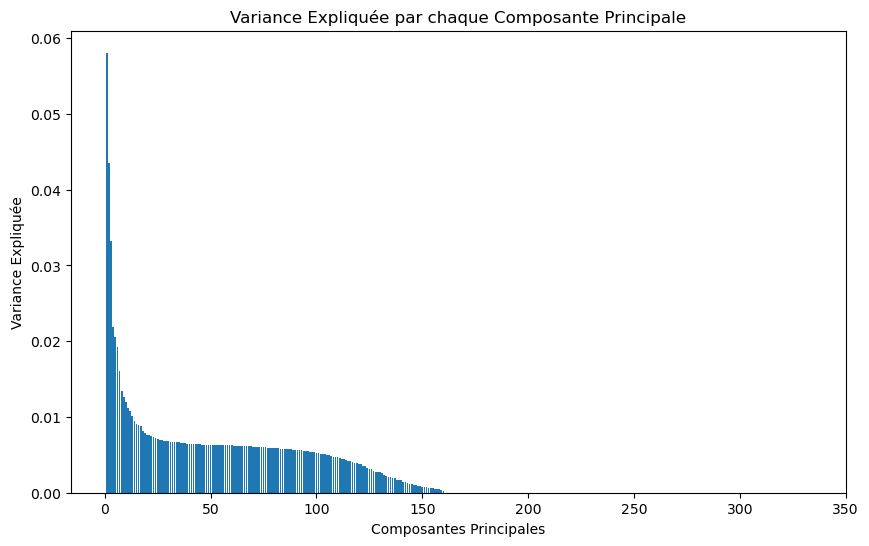

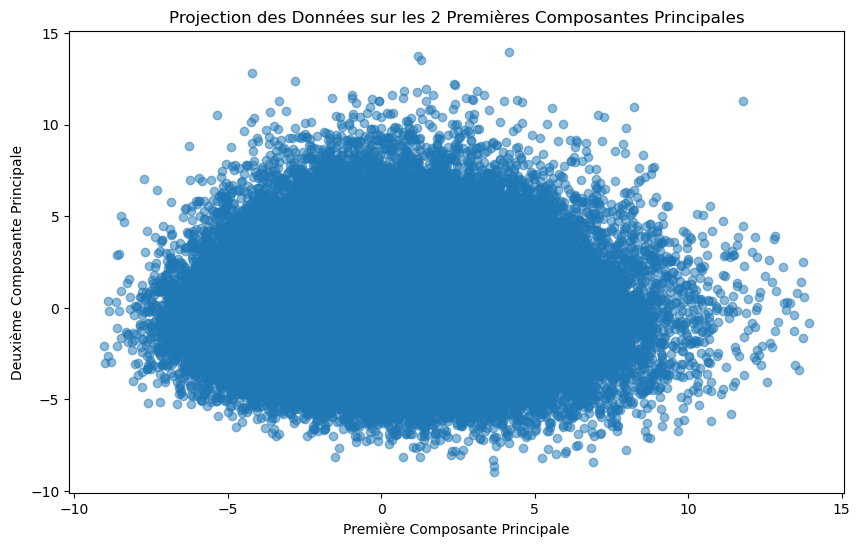

In [158]:
numeric_columns = x_df.select_dtypes(include=['int64', 'float64']).columns
x_numeric = x_df[numeric_columns]

# 1. Standardiser les données
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_numeric)

# 2.Appliquer l'APC
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

# 3. Visualisation : Varience expliquée par chaque composante principale
explained_variance = pca.explained_variance_ratio_

# 2. Obtenir les valeurs propres
eigenvalues = pca.explained_variance_

# 3. (Optionnel) Obtenir la variance expliquée (pourcentages)
explained_variance_ratio = pca.explained_variance_ratio_

# Afficher les résultats
print("Valeurs propres :", eigenvalues)
print("Variance expliquée ratio :", explained_variance_ratio)

# Affichage du graphique pour la variance expliquée par chaque composante
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Composantes Principales')
plt.ylabel('Variance Expliquée')
plt.title('Variance Expliquée par chaque Composante Principale')
plt.show()

# 4. Visualisation des 2 premières composantes principales
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], alpha=0.5)
plt.xlabel('Première Composante Principale')
plt.ylabel('Deuxième Composante Principale')
plt.title('Projection des Données sur les 2 Premières Composantes Principales')
plt.show()